<a href="https://colab.research.google.com/github/abuazfar/mas/blob/master/bn2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =============================================================================
# BLOK 1: IMPORT LIBRARY
# =============================================================================
# Library standar Python untuk operasi file, sistem, dan randomisasi
import os
import shutil
import random

# Library untuk progress bar visual (tqdm) dan numpy untuk operasi array
from tqdm import tqdm
import numpy as np

# PyTorch: Framework deep learning utama
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# Torchvision: Dataset dan transformasi gambar untuk PyTorch
from torchvision import datasets, transforms

# Scikit-learn: Untuk evaluasi model (classification report, confusion matrix)
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Google Colab: Mount Google Drive untuk akses dataset
from google.colab import drive

# Matplotlib: Visualisasi grafik training curve dan confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns


# =============================================================================
# BLOK 2: MOUNT GOOGLE DRIVE
# =============================================================================
# Mount Google Drive ke path /content/drive agar bisa akses file
# force_remount=True: Remount jika sudah pernah dimount sebelumnya
drive.mount('/content/drive', force_remount=True)


# =============================================================================
# BLOK 3: KONFIGURASI PATH DATASET
# =============================================================================
# Path sumber: Dataset asli yang belum di-split (terorganisir per folder kelas)
SOURCE_DIR = "/content/drive/MyDrive/Colab Notebooks/datasetBN"

# Path tujuan: Dataset hasil split (train/val/test) akan disimpan di sini
SPLIT_DIR = "/content/drive/MyDrive/Colab Notebooks/datasetBN_Split"

# Hapus folder split lama jika ada (untuk memastikan data fresh)
if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

# Buat ulang direktori utama split
os.makedirs(SPLIT_DIR, exist_ok=True)


# =============================================================================
# BLOK 4: SPLIT DATASET (TRAIN/VAL/TEST)
# =============================================================================
# Rasio pembagian dataset:
# - Train: 70% untuk training model
# - Validation: 15% untuk tuning hyperparameter & early stopping
# - Test: 15% untuk evaluasi akhir (data yang belum pernah dilihat model)
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# Random seed untuk reproducibility (hasil sama setiap kali run)
random.seed(42)

# Buat struktur folder: split_dir/{train,val,test}/{class_name}/
for split in ['train', 'val', 'test']:
    for cls in os.listdir(SOURCE_DIR):
        os.makedirs(os.path.join(SPLIT_DIR, split, cls), exist_ok=True)

# Proses split per kelas
for cls in os.listdir(SOURCE_DIR):
    class_path = os.path.join(SOURCE_DIR, cls)

    # Ambil semua file gambar di folder kelas
    images = os.listdir(class_path)

    # Acak urutan gambar secara random
    random.shuffle(images)

    # Hitung batas index untuk masing-masing split
    total = len(images)
    train_end = int(total * train_ratio)           # 70% pertama
    val_end = train_end + int(total * val_ratio)   # 15% berikutnya

    # Pembagian data
    train_files = images[:train_end]      # Index 0 sampai train_end
    val_files = images[train_end:val_end] # Index train_end sampai val_end
    test_files = images[val_end:]         # Sisanya untuk test

    # Copy file ke folder masing-masing dengan progress bar tqdm
    for file_list, split_name in [
        (train_files, "train"),
        (val_files, "val"),
        (test_files, "test")
    ]:
        for file in tqdm(file_list, desc=f"{cls}-{split_name}"):
            src = os.path.join(class_path, file)  # Source path
            dst = os.path.join(SPLIT_DIR, split_name, cls, file)  # Dest path
            shutil.copy(src, dst)

print(">>> Dataset split selesai!")

Mounted at /content/drive


1000-test: 100%|██████████| 51/51 [00:00<00:00, 75.82it/s]

>>> Dataset split selesai!


Classes: ['1000', '10000', '100000', '2000', '20000', '5000', '50000']
Jumlah kelas: 7
Training samples: 1671
Validation samples: 356
Test samples: 368
Using device: cuda

MULAI TRAINING


Epoch 1/50 [Val]: 100%|██████████| 12/12 [00:02<00:00,  4.06it/s, loss=0.00164]



Epoch 1/50 Summary:
  Train Loss: 1.8918 | Train Acc: 0.2597
  Val Loss:   1.5052 | Val Acc:   0.3848
  LR: 0.001000
  ✓ Model tersimpan! (Val Loss: 1.5052)


Epoch 2/50 [Val]: 100%|██████████| 12/12 [00:02<00:00,  4.13it/s, loss=0.168]



Epoch 2/50 Summary:
  Train Loss: 1.2995 | Train Acc: 0.4776
  Val Loss:   0.8806 | Val Acc:   0.6433
  LR: 0.001000
  ✓ Model tersimpan! (Val Loss: 0.8806)


...


Epoch 28/50 Summary:
  Train Loss: 0.0152 | Train Acc: 0.9946
  Val Loss:   0.0122 | Val Acc:   0.9972
  LR: 0.000125  ↓ REDUCED from 0.000250
  ✗ Tidak improvement (Patience: 3/5)


Epoch 29/50 [Val]: 100%|██████████| 12/12 [00:02<00:00,  4.18it/s, loss=0]



Epoch 29/50 Summary:
  Train Loss: 0.0115 | Train Acc: 0.9970
  Val Loss:   0.0111 | Val Acc:   0.9972
  LR: 0.000125
  ✗ Tidak improvement (Patience: 4/5)


Epoch 30/50 [Val]: 100%|██████████| 12/12 [00:03<00:00,  3.47it/s, loss=0]



Epoch 30/50 Summary:
  Train Loss: 0.0139 | Train Acc: 0.9952
  Val Loss:   0.0181 | Val Acc:   0.9944
  LR: 0.000125
  ✗ Tidak improvement (Patience: 5/5)

EARLY STOPPING TRIGGERED setelah 30 epoch!
Val loss tidak improve selama 5 epoch berturut-turut.
Model terbaik disimpan dengan Val Loss: 0.0087

TRAINING SELESAI
Model terbaik tersimpan di: /content/drive/MyDrive/Colab Notebooks/datasetBN_Split/best_model.pth


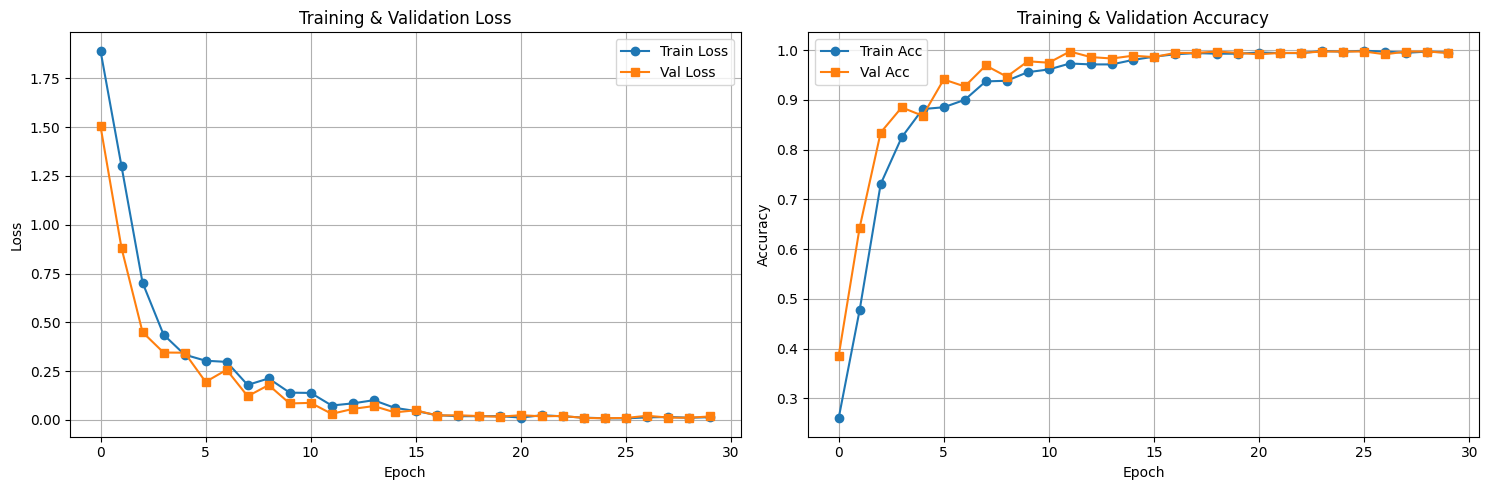

Training curve tersimpan di: /content/drive/MyDrive/Colab Notebooks/datasetBN_Split/training_curve.png

LOAD MODEL TERBAIK UNTUK EVALUASI
Model dari epoch 25 loaded.
Val Loss: 0.0087, Val Acc: 0.9972


Testing: 100%|██████████| 12/12 [00:02<00:00,  4.06it/s]



CLASSIFICATION REPORT
              precision    recall  f1-score   support

        1000     1.0000    0.9804    0.9901        51
       10000     1.0000    1.0000    1.0000        53
      100000     0.9815    1.0000    0.9907        53
        2000     1.0000    1.0000    1.0000        53
       20000     1.0000    1.0000    1.0000        53
        5000     1.0000    1.0000    1.0000        52
       50000     1.0000    1.0000    1.0000        53

    accuracy                         0.9973       368
   macro avg     0.9974    0.9972    0.9973       368
weighted avg     0.9973    0.9973    0.9973       368


Overall Test Accuracy: 0.9973 (99.73%)


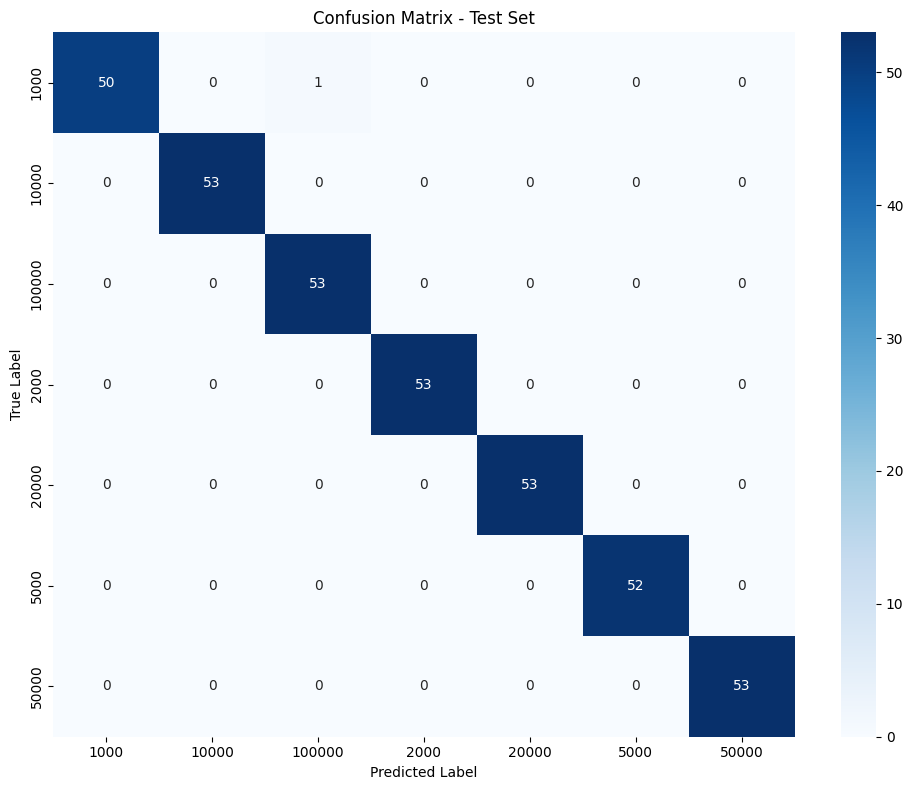


Confusion matrix tersimpan di: /content/drive/MyDrive/Colab Notebooks/datasetBN_Split/confusion_matrix.png

Model final tersimpan di: /content/drive/MyDrive/Colab Notebooks/datasetBN_Split/model_final_complete.pth

EKSPERIMEN SELESAI!


In [ ]:
# # =============================================================================
# # BLOK 1: IMPORT LIBRARY
# # =============================================================================
# # Library standar Python untuk operasi file, sistem, dan randomisasi
# import os
# import shutil
# import random

# # Library untuk progress bar visual (tqdm) dan numpy untuk operasi array
# from tqdm import tqdm
# import numpy as np

# # PyTorch: Framework deep learning utama
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import DataLoader

# # Torchvision: Dataset dan transformasi gambar untuk PyTorch
# from torchvision import datasets, transforms

# # Scikit-learn: Untuk evaluasi model (classification report, confusion matrix)
# from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# # Google Colab: Mount Google Drive untuk akses dataset
# from google.colab import drive

# # Matplotlib: Visualisasi grafik training curve dan confusion matrix
# import matplotlib.pyplot as plt
# import seaborn as sns
# from google.colab import drive

# # =============================================================================
# # BLOK 2: MOUNT GOOGLE DRIVE
# # =============================================================================
# # Mount Google Drive ke path /content/drive agar bisa akses file
# # force_remount=True: Remount jika sudah pernah dimount sebelumnya
# drive.mount('/content/drive', force_remount=True)


# # =============================================================================
# # BLOK 3: KONFIGURASI PATH DATASET
# # =============================================================================
# SPLIT_DIR = "/content/drive/MyDrive/Colab Notebooks/datasetBN_Split"

# =============================================================================
# BLOK 5: KONFIGURASI HYPERPARAMETER
# =============================================================================
IMG_SIZE = 224      # Ukuran input gambar (224x224 sesuai paper)
BATCH_SIZE = 32     # Jumlah gambar per batch (sesuai paper)
EPOCHS = 50         # Maksimum epoch (early stopping akan menghentikan jika perlu)
LEARNING_RATE = 0.001  # Learning rate awal (sesuai paper)
PATIENCE = 5        # Early stopping: berapa epoch menunggu sebelum stop jika tidak improve


# =============================================================================
# BLOK 6: DATA AUGMENTATION & PREPROCESSING
# =============================================================================
# PERBAIKAN STEP 1: Tambahkan Normalize untuk stabilisasi training
# Mean dan Std menggunakan ImageNet statistics (standar untuk CNN)

# Transformasi untuk TRAINING (dengan augmentasi)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),        # Resize ke 224x224
    transforms.RandomRotation(10),                  # Rotasi random ±10 derajat
    transforms.RandomHorizontalFlip(),              # Flip horizontal random
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # Variasi warna
    transforms.ToTensor(),                          # Convert ke tensor (0-1)
    transforms.Normalize(                           # NORMALISASI (baru ditambahkan)
        mean=[0.485, 0.456, 0.406],                 # Mean RGB ImageNet
        std=[0.229, 0.224, 0.225]                   # Std RGB ImageNet
    )
])

# Transformasi untuk VALIDATION & TEST (tanpa augmentasi, hanya preprocessing)
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),        # Resize ke 224x224
    transforms.ToTensor(),                          # Convert ke tensor
    transforms.Normalize(                           # NORMALISASI (sama dengan train)
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# =============================================================================
# BLOK 7: LOAD DATASET DENGAN IMAGEFOLDER
# =============================================================================
# ImageFolder: Otomatis membuat label dari nama folder
# Struktur: split_dir/{split}/{class_name}/images.jpg

train_dataset = datasets.ImageFolder(
    os.path.join(SPLIT_DIR, "train"),
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(SPLIT_DIR, "val"),
    transform=val_test_transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(SPLIT_DIR, "test"),
    transform=val_test_transform
)

# DataLoader: Mengelompokkan data menjadi batch
# num_workers=2: Parallel loading (lebih cepat)
# pin_memory=True: Optimasi untuk GPU
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,           # Acak setiap epoch (penting untuk training)
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,          # Tidak perlu diacak untuk val/test
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Jumlah kelas (denominasi uang) dan nama kelas
NUM_CLASSES = len(train_dataset.classes)
print("Classes:", train_dataset.classes)
print(f"Jumlah kelas: {NUM_CLASSES}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")


# =============================================================================
# BLOK 8: ARSITEKTUR CNN (DENGAN DROPOUT)
# =============================================================================
# PERBAIKAN: Tambahkan Dropout untuk regularisasi & mencegah overfitting

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()

        # Feature Extraction: 3 layer konvolusi (sesuai paper)
        self.conv = nn.Sequential(
            # Layer 1: 3 channel (RGB) → 32 filter
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 224 → 112

            # Layer 2: 32 → 64 filter
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 112 → 56

            # Layer 3: 64 → 128 filter
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)   # 56 → 28
        )

        # Classifier: Fully Connected dengan Dropout
        self.fc = nn.Sequential(
            nn.Flatten(),                    # 28x28x128 = 100352
            nn.Linear(128 * 28 * 28, 256),   # 100352 → 256
            nn.ReLU(),
            nn.Dropout(0.5),                 # DROPOUT: matikan 50% neuron random
            nn.Linear(256, num_classes)      # 256 → jumlah kelas (7)
        )

    def forward(self, x):
        x = self.conv(x)    # Ekstraksi fitur
        x = self.fc(x)      # Klasifikasi
        return x


# =============================================================================
# BLOK 9: INISIALISASI MODEL, LOSS, OPTIMIZER, & SCHEDULER
# =============================================================================
# Device: Gunakan GPU (cuda) jika tersedia, else CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Inisialisasi model
model = SimpleCNN(NUM_CLASSES).to(device)

# Loss Function: CrossEntropyLoss (standar untuk klasifikasi multi-kelas)
criterion = nn.CrossEntropyLoss()

# Optimizer: Adam dengan learning rate 0.001 (sesuai paper)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# PERBAIKAN STEP 4: Learning Rate Scheduler
# ReduceLROnPlateau: Turunkan LR jika val_loss tidak improve selama 'patience' epoch
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',         # Monitor minimalisasi val_loss
    factor=0.5,         # Kalikan LR dengan 0.5 jika trigger
    patience=2          # Tunggu 2 epoch tanpa improve sebelum turunkan LR
    # verbose dihapus karena tidak compatible dengan semua versi PyTorch
)


# =============================================================================
# BLOK 10: TRAINING LOOP (DENGAN CHECKPOINT & EARLY STOPPING)
# =============================================================================
# PERBAIKAN STEP 2 & 3: Simpan model terbaik + tracking accuracy
# PERBAIKAN STEP 5: Early stopping

# Dictionary untuk menyimpan history training (untuk plotting nanti)
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

# Variabel untuk model checkpoint & early stopping
best_val_loss = float('inf')    # Val loss terbaik (terendah) yang pernah dicapai
patience_counter = 0            # Counter epoch tanpa improvement
best_model_path = os.path.join(SPLIT_DIR, 'best_model.pth')  # Path simpan model

print("\n" + "="*60)
print("MULAI TRAINING")
print("="*60)

for epoch in range(EPOCHS):
    # =====================================================================
    # PHASE 1: TRAINING
    # =====================================================================
    model.train()  # Set mode training (dropout aktif, batch norm aktif)

    running_loss = 0.0      # Akumulasi loss
    correct_train = 0       # Jumlah prediksi benar
    total_train = 0         # Total sampel

    # Progress bar untuk training batch
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")

    for images, labels in train_pbar:
        # Pindah data ke device (GPU/CPU)
        images, labels = images.to(device), labels.to(device)

        # Zero gradient: Hapus gradient dari iterasi sebelumnya
        optimizer.zero_grad()

        # Forward pass: Hitung prediksi
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass: Hitung gradient
        loss.backward()

        # Update weights: Optimizer step
        optimizer.step()

        # Statistik
        running_loss += loss.item() * images.size(0)  # Akumulasi loss (weighted)
        _, predicted = torch.max(outputs, 1)          # Ambil kelas dengan prob tertinggi
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

        # Update progress bar dengan loss realtime
        train_pbar.set_postfix({'loss': loss.item()})

    # Hitung rata-rata loss & accuracy untuk epoch ini
    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = correct_train / total_train

    # =====================================================================
    # PHASE 2: VALIDATION
    # =====================================================================
    model.eval()  # Set mode evaluasi (dropout non-aktif)

    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    # Tidak perlu gradient untuk validation (hemat memori & lebih cepat)
    with torch.no_grad():
        val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]")

        for images, labels in val_pbar:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

            val_pbar.set_postfix({'loss': loss.item()})

    # Hitung rata-rata validation metrics
    epoch_val_loss = running_val_loss / len(val_dataset)
    epoch_val_acc = correct_val / total_val

    # =====================================================================
    # PHASE 3: UPDATE SCHEDULER & CHECKPOINT
    # =====================================================================

    # Simpan LR lama untuk cek perubahan
    old_lr = optimizer.param_groups[0]['lr']

    # Step scheduler berdasarkan val_loss
    scheduler.step(epoch_val_loss)

    # Cek apakah LR berubah
    new_lr = optimizer.param_groups[0]['lr']
    lr_changed = new_lr != old_lr

    # Simpan history
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    # Print summary epoch
    print(f"\nEpoch {epoch+1}/{EPOCHS} Summary:")
    print(f"  Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
    print(f"  Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc:.4f}")
    print(f"  LR: {new_lr:.6f}", end="")
    if lr_changed:
        print(f"  ↓ REDUCED from {old_lr:.6f}")
    else:
        print()

    # ---------------------------------------------------------------------
    # MODEL CHECKPOINT: Simpan model terbaik berdasarkan val_loss
    # ---------------------------------------------------------------------
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),  # Tambahkan scheduler state
            'val_loss': epoch_val_loss,
            'val_acc': epoch_val_acc,
        }, best_model_path)
        print(f"  ✓ Model tersimpan! (Val Loss: {epoch_val_loss:.4f})")
        patience_counter = 0  # Reset counter karena ada improvement
    else:
        patience_counter += 1  # Tidak ada improvement
        print(f"  ✗ Tidak improvement (Patience: {patience_counter}/{PATIENCE})")

    # ---------------------------------------------------------------------
    # EARLY STOPPING: Hentikan jika tidak ada improvement selama 'patience' epoch
    # ---------------------------------------------------------------------
    if patience_counter >= PATIENCE:
        print(f"\n{'='*60}")
        print(f"EARLY STOPPING TRIGGERED setelah {epoch+1} epoch!")
        print(f"Val loss tidak improve selama {PATIENCE} epoch berturut-turut.")
        print(f"Model terbaik disimpan dengan Val Loss: {best_val_loss:.4f}")
        print(f"{'='*60}")
        break

print("\n" + "="*60)
print("TRAINING SELESAI")
print(f"Model terbaik tersimpan di: {best_model_path}")
print("="*60)


# =============================================================================
# BLOK 11: VISUALISASI TRAINING CURVE
# =============================================================================
# Plot grafik loss dan accuracy untuk analisis training

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot Loss
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
axes[0].set_title('Training & Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Plot Accuracy
axes[1].plot(history['train_acc'], label='Train Acc', marker='o')
axes[1].plot(history['val_acc'], label='Val Acc', marker='s')
axes[1].set_title('Training & Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(SPLIT_DIR, 'training_curve.png'))
plt.show()
print(f"Training curve tersimpan di: {SPLIT_DIR}/training_curve.png")


# =============================================================================
# BLOK 12: LOAD MODEL TERBAIK & EVALUASI FINAL
# =============================================================================
# Load model terbaik (yang disimpan saat checkpoint) untuk evaluasi final
# Ini memastikan kita evaluasi model dengan val loss terendah, bukan model terakhir

print("\n" + "="*60)
print("LOAD MODEL TERBAIK UNTUK EVALUASI")
print("="*60)

checkpoint = torch.load(best_model_path)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Model dari epoch {checkpoint['epoch']+1} loaded.")
print(f"Val Loss: {checkpoint['val_loss']:.4f}, Val Acc: {checkpoint['val_acc']:.4f}")

# Set model ke mode evaluasi
model.eval()

# List untuk menyimpan semua prediksi dan label
all_preds = []
all_labels = []

# Inference tanpa gradient
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(device)

        # Forward pass
        outputs = model(images)

        # Ambil prediksi (kelas dengan nilai tertinggi)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# Konversi ke numpy array
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)


# =============================================================================
# BLOK 13: CLASSIFICATION REPORT
# =============================================================================
# Print classification report: Precision, Recall, F1-Score per kelas

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)

print(classification_report(
    all_labels,
    all_preds,
    target_names=train_dataset.classes,
    digits=4
))

# Hitung overall accuracy
test_accuracy = accuracy_score(all_labels, all_preds)
print(f"\nOverall Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")


# =============================================================================
# BLOK 14: CONFUSION MATRIX VISUALIZATION
# =============================================================================
# Visualisasi confusion matrix untuk analisis error per kelas

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,           # Tampilkan angka di dalam cell
    fmt='d',              # Format integer
    cmap='Blues',         # Warna biru
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(os.path.join(SPLIT_DIR, 'confusion_matrix.png'))
plt.show()
print(f"\nConfusion matrix tersimpan di: {SPLIT_DIR}/confusion_matrix.png")


# =============================================================================
# BLOK 15: SIMPAN MODEL FINAL (OPSIONAL)
# =============================================================================
# Simpan model dalam format yang bisa di-load tanpa struktur class

final_model_path = os.path.join(SPLIT_DIR, 'model_final_complete.pth')
torch.save({
    'model_state_dict': model.state_dict(),
    'classes': train_dataset.classes,
    'num_classes': NUM_CLASSES,
    'img_size': IMG_SIZE,
    'transform': val_test_transform
}, final_model_path)

print(f"\nModel final tersimpan di: {final_model_path}")
print("\n" + "="*60)
print("EKSPERIMEN SELESAI!")
print("="*60)

In [ ]:
import os
from collections import defaultdict

# Path ke folder split (tanpa /train/val/test di akhir)
SPLIT_DIR = "/content/drive/MyDrive/Colab Notebooks/datasetBN_Split"

def get_all_files(split_path):
    """Ambil semua file dari folder split dengan format: class_name/filename"""
    files = set()

    # List semua class folder di split ini (1000, 5000, 10000, dll)
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)

        # Cek apakah ini folder (bukan file)
        if os.path.isdir(class_path):
            # List semua gambar di class folder
            for filename in os.listdir(class_path):
                # Simpan sebagai "class_name/filename"
                files.add(f"{class_name}/{filename}")

    return files

# Path masing-masing split
train_path = os.path.join(SPLIT_DIR, 'train')
val_path = os.path.join(SPLIT_DIR, 'val')
test_path = os.path.join(SPLIT_DIR, 'test')

# Ambil file dari masing-masing split
train_files = get_all_files(train_path)
val_files = get_all_files(val_path)
test_files = get_all_files(test_path)

print(f"Jumlah file Train: {len(train_files)}")
print(f"Jumlah file Val:   {len(val_files)}")
print(f"Jumlah file Test:  {len(test_files)}")
print(f"Total: {len(train_files) + len(val_files) + len(test_files)}")

# Cek overlap
train_val_overlap = train_files & val_files
train_test_overlap = train_files & test_files
val_test_overlap = val_files & test_files

print(f"\n{'='*50}")
print("HASIL CEK OVERLAP:")
print(f"{'='*50}")
print(f"Train-Val overlap:   {len(train_val_overlap)} file")
print(f"Train-Test overlap:  {len(train_test_overlap)} file")
print(f"Val-Test overlap:    {len(val_test_overlap)} file")

# Tampilkan contoh jika ada overlap
if len(train_val_overlap) > 0:
    print(f"\n⚠️  Contoh file sama di Train & Val:")
    for f in list(train_val_overlap)[:3]:
        print(f"   - {f}")

if len(train_test_overlap) > 0:
    print(f"\n⚠️  Contoh file sama di Train & Test:")
    for f in list(train_test_overlap)[:3]:
        print(f"   - {f}")

if len(val_test_overlap) > 0:
    print(f"\n⚠️  Contoh file sama di Val & Test:")
    for f in list(val_test_overlap)[:3]:
        print(f"   - {f}")

# Kesimpulan
total_overlap = len(train_val_overlap) + len(train_test_overlap) + len(val_test_overlap)
print(f"\n{'='*50}")
if total_overlap == 0:
    print("✅ AMAN: Tidak ada overlap file!")
    print("   Hasil 99.73% valid.")
else:
    print(f"❌ BERBAHAYA: Ada {total_overlap} file duplikat!")
    print("   Hasil 99.73% tidak valid karena data leakage.")

Jumlah file Train: 1671
Jumlah file Val:   356
Jumlah file Test:  368
Total: 2395

HASIL CEK OVERLAP:
Train-Val overlap:   0 file
Train-Test overlap:  0 file
Val-Test overlap:    0 file

✅ AMAN: Tidak ada overlap file!
   Hasil 99.73% valid.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")  # Harusnya "cuda", bukan "cpu"

Using device: cuda
